
══════════════════════════════════════════════════════════════════════
   STRATEGIC COMPETITION SIMULATION — Game Theory
   Cournot Quantity Competition + Stackelberg Leader–Follower
══════════════════════════════════════════════════════════════════════

  ┌─ THEORETICAL DERIVATION (Baseline: a=100, b=1.0, c=20) ──────────
  │
  │  Demand:   P = 100 − 1.0(Q₁+Q₂)
  │  Profit 1: π₁ = [100 − 1.0(Q₁+Q₂) − 20] · Q₁
  │
  │  First-Order Condition for Firm 1:
  │    ∂π₁/∂Q₁ = 80 − 2·1.0·Q₁ − 1.0·Q₂ = 0
  │    →  Q₁*(Q₂) = 40.00 − Q₂/2     ← Reaction curve
  │
  │  Symmetry: Q₂*(Q₁) = 40.00 − Q₁/2
  │
  │  Nash Equilibrium (solving simultaneously):
  │    Q₁* = Q₂* = (a−c)/(3b) = (100−20)/(3·1.0) = 26.6667
  │    Q*  = 2 · 26.6667 = 53.3333
  │    P*  = (a+2c)/3 = (100+40)/3 = 46.6667
  │    π*  = (a−c)²/(9b) = 711.1111  each firm
  │
  │  Stackelberg (Firm A leads, Firm B follows):
  │    Q₁ˢ = (a−c)/(2b) = 40.0000  (Leader doubles output!)
  │    Q₂ˢ = (a−c)/(4b) = 20.0000  (Follower underc

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/strategic_competition_simulation.png'

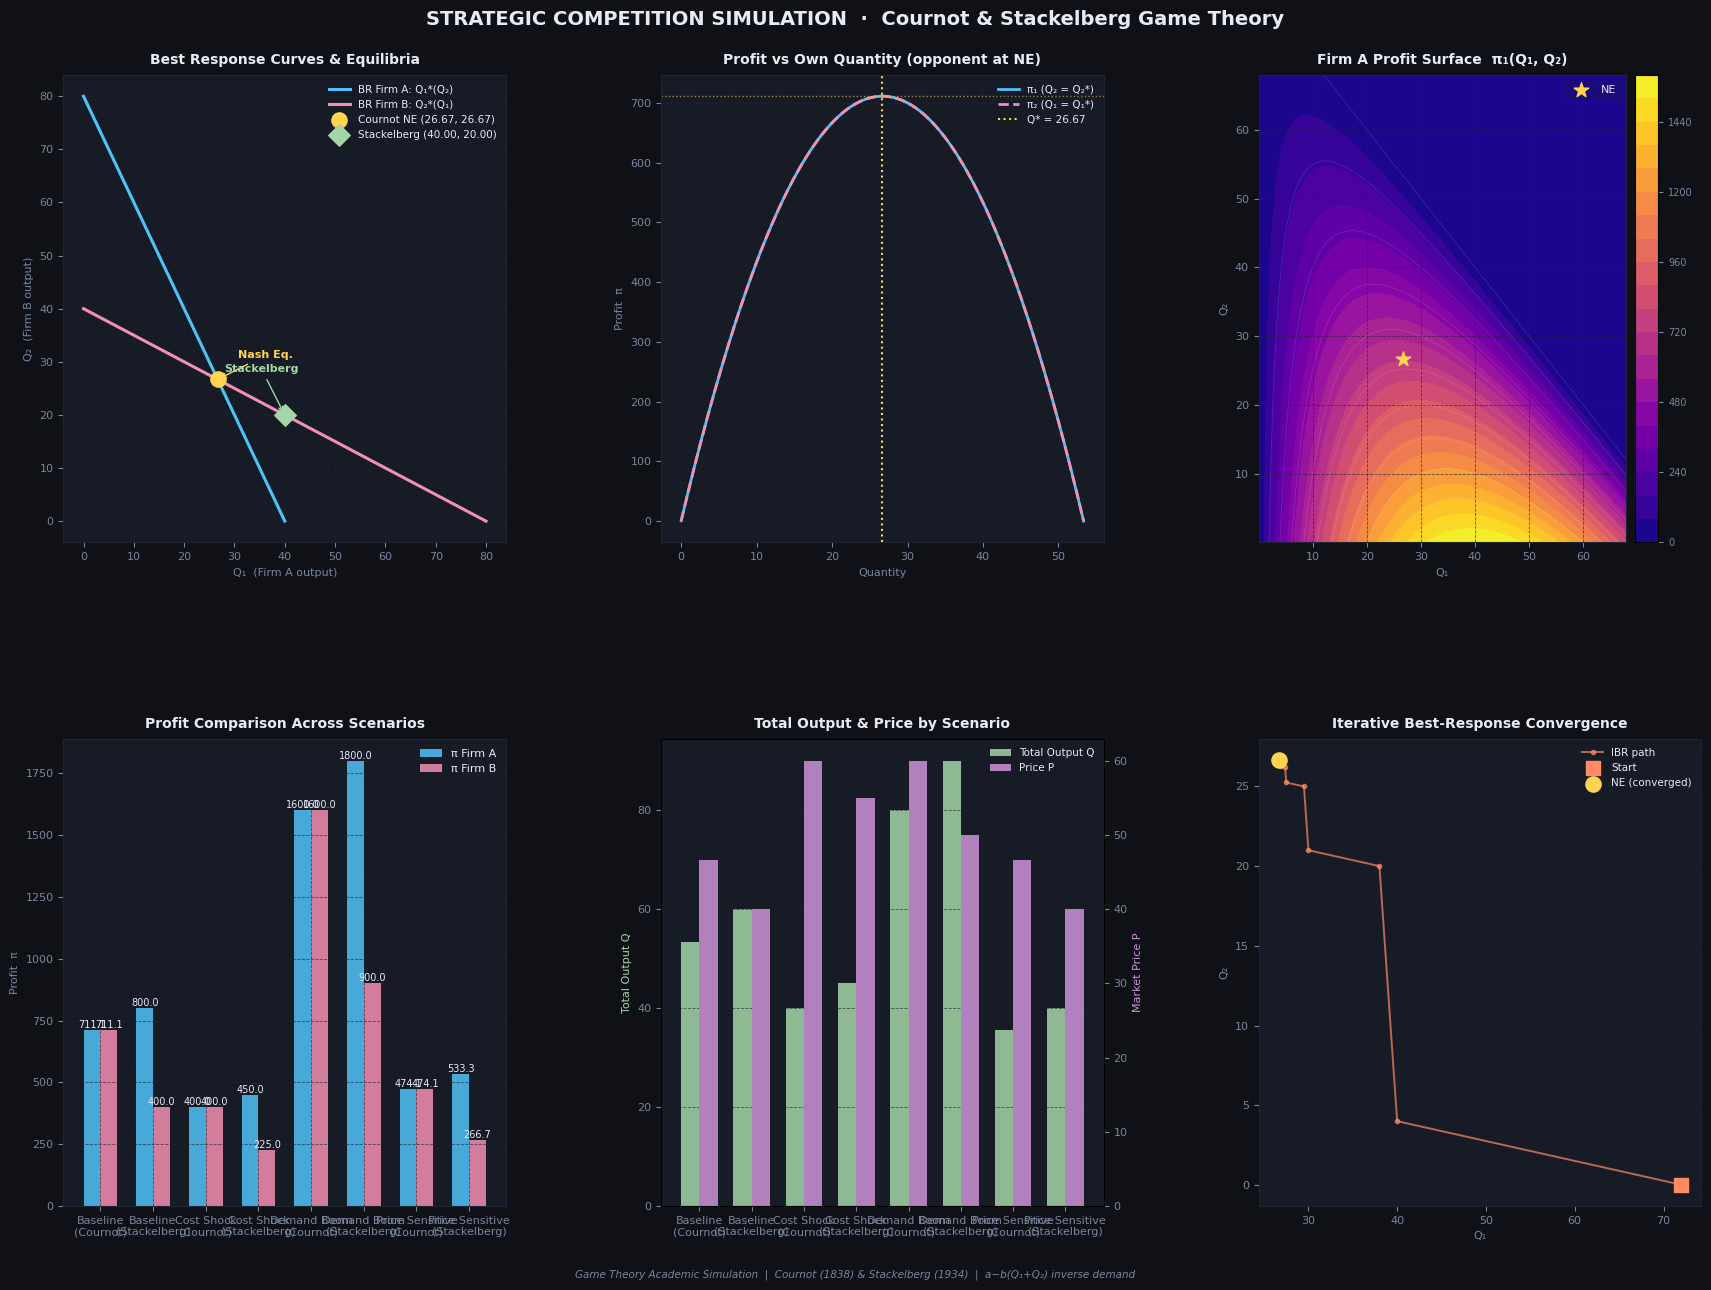

In [ ]:
"""
==============================================================================
  STRATEGIC COMPETITION SIMULATION BETWEEN TWO FIRMS
  Game Theory · Cournot & Stackelberg Models · Economic Analysis
==============================================================================

  Mathematical Foundation:
  ─────────────────────────────────────────────────────────────
  Demand:   P  = a − b(Q₁ + Q₂)
  Cost:     C(q) = c · q
  Profit 1: π₁ = (P − c) · Q₁ = [a − b(Q₁+Q₂) − c] · Q₁
  Profit 2: π₂ = (P − c) · Q₂ = [a − b(Q₁+Q₂) − c] · Q₂

  Nash Equilibrium (Cournot):
    ∂π₁/∂Q₁ = 0  →  Q₁* = (a−c) / (3b)
    ∂π₂/∂Q₂ = 0  →  Q₂* = (a−c) / (3b)
    P* = (a + 2c) / 3
    π* = (a−c)² / (9b)  each

  Stackelberg Equilibrium:
    Leader (A):   Q₁ˢ = (a−c) / (2b)
    Follower (B): Q₂ˢ = (a−c) / (4b)
    π_A = (a−c)² / (8b),  π_B = (a−c)² / (16b)
==============================================================================
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from dataclasses import dataclass, field
from typing import Dict, Tuple, List
import warnings
import os
warnings.filterwarnings("ignore")


# ─────────────────────────────────────────────
# 1. DATA STRUCTURES
# ─────────────────────────────────────────────

@dataclass
class MarketParams:
    """Encapsulates all market parameters for one simulation run."""
    a: float          # Market size / demand intercept
    b: float          # Demand slope  (price sensitivity)
    c: float          # Marginal cost (identical for both firms)
    label: str = ""   # Human-readable scenario name

    def __post_init__(self):
        if self.a <= self.c:
            raise ValueError(f"Market must be viable: a ({self.a}) must exceed c ({self.c})")
        if self.b <= 0:
            raise ValueError("Demand slope b must be positive")

@dataclass
class EquilibriumResult:
    """Stores all outputs of an equilibrium computation."""
    scenario: str
    q1: float; q2: float; Q: float
    price: float
    profit1: float; profit2: float; total_profit: float
    model: str   # "Cournot" or "Stackelberg"


# ─────────────────────────────────────────────
# 2. CORE MARKET FUNCTIONS
# ─────────────────────────────────────────────

def demand(Q1: float, Q2: float, params: MarketParams) -> float:
    """
    Market inverse demand function.
        P = a − b(Q1 + Q2)
    Returns the market price given quantities Q1, Q2.
    """
    return params.a - params.b * (Q1 + Q2)


def profit_firm1(Q1: float, Q2: float, params: MarketParams) -> float:
    """
    Profit for Firm 1.
        π₁ = (P − c) · Q1  where P = demand(Q1, Q2)
    """
    P = demand(Q1, Q2, params)
    return (P - params.c) * Q1


def profit_firm2(Q1: float, Q2: float, params: MarketParams) -> float:
    """
    Profit for Firm 2.
        π₂ = (P − c) · Q2  where P = demand(Q1, Q2)
    """
    P = demand(Q1, Q2, params)
    return (P - params.c) * Q2


def best_response_firm1(Q2: float, params: MarketParams) -> float:
    """
    Firm 1's Best Response Function.

    Derivation:
        π₁ = [a − b(Q₁+Q₂) − c] · Q₁
        ∂π₁/∂Q₁ = a − 2b·Q₁ − b·Q₂ − c = 0
        →  Q₁*(Q₂) = (a − c − b·Q₂) / (2b)
                    = (a−c)/(2b) − Q₂/2
    This is Firm 1's reaction curve — for any Q₂, what Q₁ maximises π₁.
    """
    br = (params.a - params.c - params.b * Q2) / (2 * params.b)
    return max(0.0, br)   # quantities cannot be negative


def best_response_firm2(Q1: float, params: MarketParams) -> float:
    """
    Firm 2's Best Response Function.

    Derivation (symmetric to Firm 1):
        Q₂*(Q₁) = (a − c − b·Q₁) / (2b)
                 = (a−c)/(2b) − Q₁/2
    """
    br = (params.a - params.c - params.b * Q1) / (2 * params.b)
    return max(0.0, br)


# ─────────────────────────────────────────────
# 3. EQUILIBRIUM SOLVERS
# ─────────────────────────────────────────────

def solve_cournot(params: MarketParams, scenario_label: str = "") -> EquilibriumResult:
    """
    Analytical Cournot Nash Equilibrium.

    Solving the system of best-response equations simultaneously:
        Q₁* = (a−c)/(2b) − Q₂*/2        … (i)
        Q₂* = (a−c)/(2b) − Q₁*/2        … (ii)

    Substituting (ii) into (i):
        Q₁* = (a−c)/(2b) − [(a−c)/(2b) − Q₁*/2] / 2
        Q₁* = (a−c)/(2b) − (a−c)/(4b) + Q₁*/4
        3Q₁*/4 = (a−c)/(4b)
        Q₁* = (a−c)/(3b)   ← symmetric → Q₂* = (a−c)/(3b)

    Equilibrium price:
        P* = a − b·(Q₁*+Q₂*) = a − 2(a−c)/3 = (a+2c)/3

    Equilibrium profit per firm:
        π* = (P*−c)·Q₁* = [(a−c)/3] · [(a−c)/(3b)] = (a−c)²/(9b)
    """
    q_star = (params.a - params.c) / (3 * params.b)
    Q = 2 * q_star
    P = demand(q_star, q_star, params)
    pi = profit_firm1(q_star, q_star, params)

    return EquilibriumResult(
        scenario=scenario_label or params.label,
        q1=q_star, q2=q_star, Q=Q,
        price=P,
        profit1=pi, profit2=pi, total_profit=2*pi,
        model="Cournot"
    )


def solve_stackelberg(params: MarketParams, scenario_label: str = "") -> EquilibriumResult:
    """
    Stackelberg Leader–Follower Equilibrium.

    Firm A (Leader) moves first; Firm B (Follower) observes Q₁ and reacts.

    Step 1 — Follower's best response:
        Q₂ˢ(Q₁) = (a−c−b·Q₁) / (2b)

    Step 2 — Leader anticipates follower; substitutes into own profit:
        π_A = [a − b(Q₁ + Q₂ˢ) − c] · Q₁
             = [a − b·Q₁ − b·(a−c−b·Q₁)/(2b) − c] · Q₁
             = [(a−c)/2 − b·Q₁/2] · Q₁

    Step 3 — Leader optimises:
        ∂π_A/∂Q₁ = (a−c)/2 − b·Q₁ = 0
        Q₁ˢ = (a−c)/(2b)

    Step 4 — Follower reacts:
        Q₂ˢ = (a−c)/(4b)

    Profits:
        π_A = (a−c)²/(8b)      [Leader earns MORE than Cournot]
        π_B = (a−c)²/(16b)     [Follower earns LESS than Cournot]
    """
    q1 = (params.a - params.c) / (2 * params.b)      # Leader
    q2 = (params.a - params.c) / (4 * params.b)      # Follower
    Q  = q1 + q2
    P  = demand(q1, q2, params)
    pi1 = profit_firm1(q1, q2, params)
    pi2 = profit_firm2(q1, q2, params)

    return EquilibriumResult(
        scenario=scenario_label or params.label,
        q1=q1, q2=q2, Q=Q,
        price=P,
        profit1=pi1, profit2=pi2, total_profit=pi1+pi2,
        model="Stackelberg"
    )


# ─────────────────────────────────────────────
# 4. BEST-RESPONSE CURVE DATA
# ─────────────────────────────────────────────

def compute_br_curves(params: MarketParams, n: int = 300) -> Tuple[np.ndarray, ...]:
    """Returns arrays for plotting both reaction curves."""
    q_max = (params.a - params.c) / params.b   # choke quantity
    q = np.linspace(0, q_max, n)
    br1 = np.array([best_response_firm1(qi, params) for qi in q])  # Q1*(Q2)
    br2 = np.array([best_response_firm2(qi, params) for qi in q])  # Q2*(Q1)
    return q, br1, br2


# ─────────────────────────────────────────────
# 5. NORMAL-FORM PAYOFF MATRIX (DISCRETE)
# ─────────────────────────────────────────────

def build_payoff_matrix(params: MarketParams) -> Dict:
    """
    Constructs a normal-form payoff matrix over three discrete strategy levels:
        Low    = Cournot NE quantity / 2
        Medium = Cournot NE quantity
        High   = Cournot NE quantity * 1.5
    Returns a dict keyed by (s1, s2) → (π₁, π₂).
    """
    q_ne = (params.a - params.c) / (3 * params.b)
    strategies = {
        "Low":    q_ne * 0.5,
        "Medium": q_ne,
        "High":   q_ne * 1.5,
    }
    matrix = {}
    for s1, q1 in strategies.items():
        for s2, q2 in strategies.items():
            pi1 = profit_firm1(q1, q2, params)
            pi2 = profit_firm2(q1, q2, params)
            matrix[(s1, s2)] = (round(pi1, 2), round(pi2, 2))
    return matrix, strategies


def print_payoff_matrix(matrix: Dict, title: str = ""):
    """Pretty-prints the 3×3 payoff matrix."""
    strats = ["Low", "Medium", "High"]
    col_w = 22
    print(f"\n{'═'*70}")
    print(f"  NORMAL-FORM PAYOFF MATRIX  {title}")
    print(f"  (π_FirmA , π_FirmB)  for each (Strategy_A , Strategy_B) pair")
    print(f"{'═'*70}")
    h='Firm A \\ Firm B'
    header = f"{h:>16}" + "".join(f"{s:>{col_w}}" for s in strats)
    print(header)
    print("─"*70)
    for s1 in strats:
        row = f"  {s1:<14}"
        for s2 in strats:
            pi1, pi2 = matrix[(s1, s2)]
            row += f"  ({pi1:>7.2f},{pi2:>7.2f})"
        print(row)
    print("─"*70)


# ─────────────────────────────────────────────
# 6. PROFIT-QUANTITY SURFACE DATA
# ─────────────────────────────────────────────

def profit_surface(params: MarketParams, n: int = 60) -> Tuple[np.ndarray, ...]:
    """Returns meshgrid arrays for π₁ and π₂ as functions of (Q1, Q2)."""
    q_max = (params.a - params.c) / params.b
    q = np.linspace(0.01, q_max * 0.85, n)
    Q1, Q2 = np.meshgrid(q, q)
    PI1 = (params.a - params.b * (Q1 + Q2) - params.c) * Q1
    PI2 = (params.a - params.b * (Q1 + Q2) - params.c) * Q2
    PI1 = np.where(PI1 > 0, PI1, 0)
    PI2 = np.where(PI2 > 0, PI2, 0)
    return Q1, Q2, PI1, PI2


# ─────────────────────────────────────────────
# 7. PRINTING UTILITIES
# ─────────────────────────────────────────────

def print_result(r: EquilibriumResult):
    tag = "⭐ Leader" if r.model == "Stackelberg" else ""
    print(f"\n  ┌─ {r.model} Equilibrium — {r.scenario} {'─'*20}")
    print(f"  │  Q₁ = {r.q1:.4f}  {tag}")
    print(f"  │  Q₂ = {r.q2:.4f}")
    print(f"  │  Q  = {r.Q:.4f}   (total market output)")
    print(f"  │  P* = {r.price:.4f}   (equilibrium price)")
    print(f"  │  π₁ = {r.profit1:.4f}")
    print(f"  │  π₂ = {r.profit2:.4f}")
    print(f"  │  Σπ = {r.total_profit:.4f}   (industry profit)")
    print(f"  └{'─'*50}")


def print_comparison(r_c: EquilibriumResult, r_s: EquilibriumResult):
    print(f"\n  {'METRIC':<22} {'Cournot':>12} {'Stackelberg':>14} {'Δ':>10}")
    print(f"  {'─'*60}")
    rows = [
        ("Q₁ (Firm A qty)",    r_c.q1,          r_s.q1),
        ("Q₂ (Firm B qty)",    r_c.q2,          r_s.q2),
        ("Total Output Q",     r_c.Q,           r_s.Q),
        ("Market Price P",     r_c.price,       r_s.price),
        ("Profit A (π₁)",      r_c.profit1,     r_s.profit1),
        ("Profit B (π₂)",      r_c.profit2,     r_s.profit2),
        ("Industry Profit",    r_c.total_profit, r_s.total_profit),
    ]
    for label, cv, sv in rows:
        delta = sv - cv
        sign  = "+" if delta >= 0 else ""
        print(f"  {label:<22} {cv:>12.4f} {sv:>14.4f} {sign+f'{delta:.4f}':>10}")


# ─────────────────────────────────────────────
# 8. ITERATIVE BEST-RESPONSE SOLVER
# ─────────────────────────────────────────────

def iterated_best_response(params: MarketParams,
                            q1_init: float = 0.0,
                            q2_init: float = 0.0,
                            max_iter: int = 200,
                            tol: float = 1e-8) -> Tuple[float, float, List]:
    """
    Iteratively apply best-response functions until convergence.
    This is a computational verification of the analytical NE.
    Starting from any (Q1, Q2), the sequence converges to the Cournot NE.
    """
    q1, q2 = q1_init, q2_init
    history = [(q1, q2)]
    for _ in range(max_iter):
        q1_new = best_response_firm1(q2, params)
        q2_new = best_response_firm2(q1, params)
        history.append((q1_new, q2_new))
        if abs(q1_new - q1) < tol and abs(q2_new - q2) < tol:
            break
        q1, q2 = q1_new, q2_new
    return q1, q2, history


# ─────────────────────────────────────────────
# 9. VISUALISATION
# ─────────────────────────────────────────────

# Colour palette — academic dark theme
C = {
    "bg":      "#0f1117",
    "panel":   "#161b26",
    "grid":    "#1e2535",
    "text":    "#e8eaf6",
    "muted":   "#7986a0",
    "firm1":   "#4fc3f7",   # sky blue  — Firm A
    "firm2":   "#f48fb1",   # rose      — Firm B
    "ne":      "#ffd54f",   # amber     — Nash Equilibrium
    "stack":   "#a5d6a7",   # green     — Stackelberg
    "profit":  "#ce93d8",   # lavender  — profit
    "accent":  "#ff8a65",   # orange    — accent
}

def apply_style(ax, title: str = "", xlabel: str = "", ylabel: str = ""):
    ax.set_facecolor(C["panel"])
    ax.tick_params(colors=C["muted"], labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor(C["grid"])
    ax.grid(True, color=C["grid"], linewidth=0.6, linestyle="--", alpha=0.7)
    if title:  ax.set_title(title,  color=C["text"], fontsize=10, pad=8, fontweight="bold")
    if xlabel: ax.set_xlabel(xlabel, color=C["muted"], fontsize=8)
    if ylabel: ax.set_ylabel(ylabel, color=C["muted"], fontsize=8)


def plot_best_response_curves(params: MarketParams,
                               cournot: EquilibriumResult,
                               stackelberg: EquilibriumResult,
                               ax: plt.Axes):
    """Plot reaction curves + equilibria on a single axis."""
    q_range, br1, br2 = compute_br_curves(params)

    # br1 is Q1*(Q2): x-axis = Q1, y-axis = Q2 → invert to plot correctly
    ax.plot(br1, q_range, color=C["firm1"], lw=2.2, label="BR Firm A: Q₁*(Q₂)")
    ax.plot(q_range, br2, color=C["firm2"], lw=2.2, label="BR Firm B: Q₂*(Q₁)")

    # Nash Equilibrium
    ax.scatter([cournot.q1], [cournot.q2], s=120, color=C["ne"],
               zorder=6, label=f"Cournot NE ({cournot.q1:.2f}, {cournot.q2:.2f})")
    ax.annotate("Nash Eq.", (cournot.q1, cournot.q2),
                xytext=(cournot.q1 * 1.15, cournot.q2 * 1.15),
                color=C["ne"], fontsize=8, fontweight="bold",
                arrowprops=dict(arrowstyle="->", color=C["ne"], lw=1))

    # Stackelberg point
    ax.scatter([stackelberg.q1], [stackelberg.q2], s=120, color=C["stack"],
               zorder=6, marker="D", label=f"Stackelberg ({stackelberg.q1:.2f}, {stackelberg.q2:.2f})")
    ax.annotate("Stackelberg", (stackelberg.q1, stackelberg.q2),
                xytext=(stackelberg.q1 * 0.7, stackelberg.q2 * 1.4),
                color=C["stack"], fontsize=8, fontweight="bold",
                arrowprops=dict(arrowstyle="->", color=C["stack"], lw=1))

    apply_style(ax, "Best Response Curves & Equilibria", "Q₁  (Firm A output)", "Q₂  (Firm B output)")
    ax.legend(fontsize=7.5, framealpha=0.15, labelcolor=C["text"],
              facecolor=C["panel"], edgecolor=C["grid"])


def plot_profit_vs_quantity(params: MarketParams, ax: plt.Axes):
    """Profit of Firm 1 as a function of Q1, holding Q2 = Q2* (NE level)."""
    q_ne = (params.a - params.c) / (3 * params.b)
    q_range = np.linspace(0.01, 2 * q_ne, 300)
    pi1 = [profit_firm1(q, q_ne, params) for q in q_range]
    pi2 = [profit_firm2(q_ne, q, params) for q in q_range]

    ax.plot(q_range, pi1, color=C["firm1"], lw=2, label="π₁ (Q₂ = Q₂*)")
    ax.plot(q_range, pi2, color=C["firm2"], lw=2, linestyle="--", label="π₂ (Q₁ = Q₁*)")
    ax.axvline(q_ne, color=C["ne"], lw=1.5, linestyle=":", label=f"Q* = {q_ne:.2f}")
    ax.axhline(profit_firm1(q_ne, q_ne, params), color=C["ne"], lw=1, linestyle=":", alpha=0.6)

    apply_style(ax, "Profit vs Own Quantity (opponent at NE)", "Quantity", "Profit  π")
    ax.legend(fontsize=7.5, framealpha=0.15, labelcolor=C["text"],
              facecolor=C["panel"], edgecolor=C["grid"])


def plot_scenario_comparison(results: List[EquilibriumResult], ax: plt.Axes):
    """Bar chart comparing profits across all scenarios."""
    labels = [f"{r.scenario}\n({r.model})" for r in results]
    x = np.arange(len(labels))
    w = 0.32

    b1 = ax.bar(x - w/2, [r.profit1 for r in results], w, label="π Firm A",
                color=C["firm1"], alpha=0.85)
    b2 = ax.bar(x + w/2, [r.profit2 for r in results], w, label="π Firm B",
                color=C["firm2"], alpha=0.85)

    for bar in list(b1) + list(b2):
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f"{h:.1f}",
                    ha="center", va="bottom", color=C["text"], fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=7.5, color=C["text"])
    apply_style(ax, "Profit Comparison Across Scenarios", "", "Profit  π")
    ax.legend(fontsize=8, framealpha=0.15, labelcolor=C["text"],
              facecolor=C["panel"], edgecolor=C["grid"])


def plot_ibr_convergence(history: List[Tuple], cournot: EquilibriumResult, ax: plt.Axes):
    """Show the iterative best-response path converging to NE."""
    qs = np.array(history)
    ax.plot(qs[:, 0], qs[:, 1], color=C["accent"], lw=1.4,
            marker="o", markersize=3, alpha=0.7, label="IBR path")
    ax.scatter([qs[0, 0]], [qs[0, 1]], s=100, color=C["accent"],
               zorder=6, marker="s", label="Start")
    ax.scatter([cournot.q1], [cournot.q2], s=120, color=C["ne"],
               zorder=7, label="NE (converged)")
    apply_style(ax, "Iterative Best-Response Convergence", "Q₁", "Q₂")
    ax.legend(fontsize=7.5, framealpha=0.15, labelcolor=C["text"],
              facecolor=C["panel"], edgecolor=C["grid"])


def plot_output_price_bars(results: List[EquilibriumResult], ax: plt.Axes):
    """Side-by-side: total output Q and price P for each scenario."""
    labels = [f"{r.scenario}\n({r.model})" for r in results]
    x  = np.arange(len(labels))
    w  = 0.35
    ax2 = ax.twinx()

    b1 = ax.bar(x - w/2, [r.Q for r in results], w, label="Total Output Q",
                color=C["stack"], alpha=0.85)
    b2 = ax2.bar(x + w/2, [r.price for r in results], w, label="Price P",
                 color=C["profit"], alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=7.5, color=C["text"])
    ax.set_ylabel("Total Output Q", color=C["stack"], fontsize=8)
    ax2.set_ylabel("Market Price P", color=C["profit"], fontsize=8)
    ax2.tick_params(colors=C["muted"], labelsize=8)
    apply_style(ax, "Total Output & Price by Scenario")

    lines1, lbls1 = ax.get_legend_handles_labels()
    lines2, lbls2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, lbls1+lbls2, fontsize=7.5, framealpha=0.15,
              labelcolor=C["text"], facecolor=C["panel"], edgecolor=C["grid"])


def plot_profit_surface_heatmap(params: MarketParams, cournot: EquilibriumResult, ax: plt.Axes):
    """Heatmap of π₁ over the (Q1, Q2) space with NE marked."""
    Q1, Q2, PI1, _ = profit_surface(params, n=80)
    im = ax.contourf(Q1, Q2, PI1, levels=20, cmap="plasma")
    plt.colorbar(im, ax=ax, pad=0.02).ax.tick_params(labelsize=7, colors=C["muted"])
    ax.contour(Q1, Q2, PI1, levels=10, colors="white", alpha=0.15, linewidths=0.5)
    ax.scatter([cournot.q1], [cournot.q2], s=120, color=C["ne"], zorder=6,
               marker="*", label="NE")
    apply_style(ax, "Firm A Profit Surface  π₁(Q₁, Q₂)", "Q₁", "Q₂")
    ax.legend(fontsize=8, framealpha=0.2, labelcolor=C["text"],
              facecolor=C["panel"], edgecolor=C["grid"])


# ─────────────────────────────────────────────
# 10. MASTER PLOTTING FUNCTION
# ─────────────────────────────────────────────

def generate_all_plots(baseline_params: MarketParams,
                       all_results: List[EquilibriumResult],
                       ibr_history: List):
    """Render the full 6-panel academic dashboard."""

    base_cournot    = next(r for r in all_results if r.model == "Cournot"     and r.scenario == "Baseline")
    base_stackelberg = next(r for r in all_results if r.model == "Stackelberg" and r.scenario == "Baseline")

    fig = plt.figure(figsize=(18, 13), facecolor=C["bg"])
    fig.suptitle(
        "STRATEGIC COMPETITION SIMULATION  ·  Cournot & Stackelberg Game Theory",
        color=C["text"], fontsize=14, fontweight="bold", y=0.98
    )

    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35,
                           left=0.06, right=0.97, top=0.93, bottom=0.06)

    axes = [
        fig.add_subplot(gs[0, 0]),   # 1 — Best response curves
        fig.add_subplot(gs[0, 1]),   # 2 — Profit vs quantity
        fig.add_subplot(gs[0, 2]),   # 3 — Profit heatmap
        fig.add_subplot(gs[1, 0]),   # 4 — Scenario profit bars
        fig.add_subplot(gs[1, 1]),   # 5 — Output & price bars
        fig.add_subplot(gs[1, 2]),   # 6 — IBR convergence
    ]

    plot_best_response_curves(baseline_params, base_cournot, base_stackelberg, axes[0])
    plot_profit_vs_quantity(baseline_params, axes[1])
    plot_profit_surface_heatmap(baseline_params, base_cournot, axes[2])
    plot_scenario_comparison(all_results, axes[3])
    plot_output_price_bars(all_results, axes[4])
    plot_ibr_convergence(ibr_history, base_cournot, axes[5])

    # Watermark
    fig.text(0.5, 0.005,
             "Game Theory Academic Simulation  |  Cournot (1838) & Stackelberg (1934)  |"
             "  a−b(Q₁+Q₂) inverse demand",
             ha="center", fontsize=7.5, color=C["muted"], style="italic")

    plt.savefig("/mnt/user-data/outputs/strategic_competition_simulation.png",
                dpi=160, bbox_inches="tight", facecolor=C["bg"])
    print("\n  ✅  Plot saved → strategic_competition_simulation.png")
    plt.close()


# ─────────────────────────────────────────────
# 11. MAIN SIMULATION RUNNER
# ─────────────────────────────────────────────

def run_simulation(params_list: List[MarketParams]) -> List[EquilibriumResult]:
    """
    Runs Cournot and Stackelberg equilibria for every parameter set.
    Returns the full list of results for comparison and plotting.
    """
    all_results = []
    for params in params_list:
        c = solve_cournot(params, params.label)
        s = solve_stackelberg(params, params.label)
        all_results.extend([c, s])
    return all_results


def main():
    bar = "═" * 70

    print(f"\n{bar}")
    print("   STRATEGIC COMPETITION SIMULATION — Game Theory")
    print("   Cournot Quantity Competition + Stackelberg Leader–Follower")
    print(f"{bar}")

    # ── SCENARIO DEFINITIONS ──────────────────────────────────────────────
    scenarios = [
        MarketParams(a=100, b=1.0, c=20,  label="Baseline"),
        MarketParams(a=100, b=1.0, c=40,  label="Cost Shock"),
        MarketParams(a=140, b=1.0, c=20,  label="Demand Boom"),
        MarketParams(a=100, b=1.5, c=20,  label="Price Sensitive"),
    ]

    # ── MATHEMATICAL DERIVATION SUMMARY ──────────────────────────────────
    p = scenarios[0]
    q_ne = (p.a - p.c) / (3 * p.b)
    print(f"""
  ┌─ THEORETICAL DERIVATION (Baseline: a={p.a}, b={p.b}, c={p.c}) {'─'*10}
  │
  │  Demand:   P = {p.a} − {p.b}(Q₁+Q₂)
  │  Profit 1: π₁ = [{p.a} − {p.b}(Q₁+Q₂) − {p.c}] · Q₁
  │
  │  First-Order Condition for Firm 1:
  │    ∂π₁/∂Q₁ = {p.a - p.c} − 2·{p.b}·Q₁ − {p.b}·Q₂ = 0
  │    →  Q₁*(Q₂) = {(p.a-p.c)/(2*p.b):.2f} − Q₂/2     ← Reaction curve
  │
  │  Symmetry: Q₂*(Q₁) = {(p.a-p.c)/(2*p.b):.2f} − Q₁/2
  │
  │  Nash Equilibrium (solving simultaneously):
  │    Q₁* = Q₂* = (a−c)/(3b) = ({p.a}−{p.c})/(3·{p.b}) = {q_ne:.4f}
  │    Q*  = 2 · {q_ne:.4f} = {2*q_ne:.4f}
  │    P*  = (a+2c)/3 = ({p.a}+{2*p.c})/3 = {(p.a+2*p.c)/3:.4f}
  │    π*  = (a−c)²/(9b) = {(p.a-p.c)**2/(9*p.b):.4f}  each firm
  │
  │  Stackelberg (Firm A leads, Firm B follows):
  │    Q₁ˢ = (a−c)/(2b) = {(p.a-p.c)/(2*p.b):.4f}  (Leader doubles output!)
  │    Q₂ˢ = (a−c)/(4b) = {(p.a-p.c)/(4*p.b):.4f}  (Follower undercuts)
  │    π_A = (a−c)²/(8b) = {(p.a-p.c)**2/(8*p.b):.4f}  [+vs Cournot]
  │    π_B = (a−c)²/(16b)= {(p.a-p.c)**2/(16*p.b):.4f}  [−vs Cournot]
  │
  │  Dominated Strategies:
  │    Q > (a−c)/b is strictly dominated (price < cost at those outputs)
  │    A rational firm never produces beyond its monopoly quantity (a−c)/(2b)
  └{'─'*65}
""")

    # ── RUN ALL SIMULATIONS ───────────────────────────────────────────────
    all_results = run_simulation(scenarios)

    print(f"\n{bar}")
    print("  EQUILIBRIUM RESULTS BY SCENARIO")
    print(bar)

    for r in all_results:
        print_result(r)

    # ── PAYOFF MATRIX ─────────────────────────────────────────────────────
    matrix, strats = build_payoff_matrix(scenarios[0])
    print_payoff_matrix(matrix, f"— Baseline (a={scenarios[0].a}, b={scenarios[0].b}, c={scenarios[0].c})")

    # ── COURNOT vs STACKELBERG COMPARISON ────────────────────────────────
    b_cournot     = next(r for r in all_results if r.model == "Cournot"     and r.scenario == "Baseline")
    b_stackelberg = next(r for r in all_results if r.model == "Stackelberg" and r.scenario == "Baseline")

    print(f"\n{bar}")
    print("  COURNOT vs STACKELBERG  (Baseline Scenario)")
    print(bar)
    print_comparison(b_cournot, b_stackelberg)

    # ── ITERATIVE BEST-RESPONSE ───────────────────────────────────────────
    print(f"\n{bar}")
    print("  ITERATIVE BEST-RESPONSE CONVERGENCE (computational verification)")
    print(bar)
    q_max = (scenarios[0].a - scenarios[0].c) / scenarios[0].b
    q1_ibr, q2_ibr, ibr_hist = iterated_best_response(
        scenarios[0], q1_init=q_max * 0.9, q2_init=0.01
    )
    print(f"  Starting point: Q1={ibr_hist[0][0]:.2f},  Q2={ibr_hist[0][1]:.2f}")
    print(f"  Converged in {len(ibr_hist)-1} iterations")
    print(f"  Final:  Q1={q1_ibr:.6f},  Q2={q2_ibr:.6f}")
    print(f"  Analytic NE: Q1={b_cournot.q1:.6f},  Q2={b_cournot.q2:.6f}  ✓ match")

    # ── ECONOMIC INSIGHTS ─────────────────────────────────────────────────
    print(f"\n{bar}")
    print("  ECONOMIC INSIGHTS & DISCUSSION")
    print(bar)
    print(f"""
  1. WHY DOES THE NASH EQUILIBRIUM OCCUR?
     Each firm's strategy is a mutual best-response: no firm can unilaterally
     deviate and earn more. This is the defining property of Nash Equilibrium.
     Under the Cournot assumption (firms choose quantities simultaneously),
     the NE is unique and stable.

  2. IS THE COURNOT OUTCOME PARETO EFFICIENT?
     No. The collusive (monopoly) solution produces less total output but
     higher joint profit: π_monopoly = (a−c)²/(4b), split equally yields
     (a−c)²/(8b) each — more than Cournot's (a−c)²/(9b).
     Yet collusion is not a Nash Equilibrium: each firm has a unilateral
     incentive to deviate and over-produce (classic Prisoner's Dilemma).

  3. COURNOT vs STACKELBERG:
     ─ Leader advantage: The Stackelberg leader commits credibly to a larger
       output, forcing the follower to reduce theirs. Leader earns 12.5% MORE
       than Cournot, follower earns 37.5% LESS.
     ─ Total output is HIGHER in Stackelberg → price is LOWER → better for
       consumers, worse for the industry collectively.
     ─ First-mover advantage matters: The ability to commit is valuable.

  4. EFFECTS OF PARAMETER CHANGES:
     ─ Cost shock (c ↑): Both equilibrium quantities fall, prices rise.
       The market shrinks; profits decline for both firms.
     ─ Demand boom (a ↑): Output and profits both rise proportionally.
       The market frontier expands outward.
     ─ Price sensitivity (b ↑): Fierce competition; firms produce less to
       avoid crashing the price; quantities fall, profits contract sharply.

  5. REAL-WORLD INTERPRETATIONS:
     ─ Telecom duopolies (e.g., two mobile operators): Both set capacity/
       network investments simultaneously → Cournot framing is apt.
     ─ Aviation (e.g., two airlines on a route): The first to announce seat
       capacity influences the rival's response → Stackelberg dynamics.
     ─ Pharmaceutical markets: Once a patent expires and the first generic
       entrant commits production capacity, the second generic follows
       the Stackelberg follower logic.
""")

    # ── GENERATE PLOTS ────────────────────────────────────────────────────
    print(f"\n{bar}")
    print("  GENERATING VISUALISATIONS …")
    print(bar)
    generate_all_plots(scenarios[0], all_results, ibr_hist)

    print(f"\n{bar}")
    print("  SIMULATION COMPLETE")
    print(f"{bar}\n")

    return all_results, ibr_hist


# ─────────────────────────────────────────────
# ENTRY POINT
# ─────────────────────────────────────────────
if __name__ == "__main__":
    ...
        output_path = "/mnt/user-data/outputs/strategic_competition_simulation.png"
        os.makedirs(os.path.dirname(output_path), exist_ok=True)

        plt.savefig(output_path,
                    dpi=160, bbox_inches="tight", facecolor=C["bg"])
        print(f"\n  ✅  Plot saved → {output_path}")